In [12]:
# ============================================================
# Cell 1 — Load probability vectors from disk
# ------------------------------------------------------------
# All probability vectors (HW + exact for n=2,3,4) live in
# string_order_data.json next to this notebook. To regenerate,
# run `python build_string_order_data.py`.
#
# pip install scienceplots   # if not already installed
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import scienceplots  # noqa: F401  (registers the 'science' style)

with open("string_order_data.json") as f:
    DATA = json.load(f)

STATES = DATA["states"]
THERMO = 4 / 9

for name, s in STATES.items():
    hw_info = "MISSING" if s["hw"] is None else f"len={len(s['hw'])}"
    print(f"  {name}: n={s['n']}  shots={s['shots']}  hw {hw_info}  exact len={len(s['exact'])}")


  gs2a: n=2  shots=1000  hw len=9  exact len=9
  gs2b: n=2  shots=1000  hw len=9  exact len=9
  gs2c: n=2  shots=1000  hw len=9  exact len=9
  gs3a: n=3  shots=1000  hw len=27  exact len=27
  gs3b: n=3  shots=1000  hw len=27  exact len=27
  gs4a: n=4  shots=1000  hw len=81  exact len=81
  gs4b: n=4  shots=1000  hw len=81  exact len=81


In [13]:
# ============================================================
# Cell 2 — String-order primitives
# ------------------------------------------------------------
# Three functions drive the rest of the notebook:
#   compute_string_order(p)         -> {(i,j): {'correlator','string_order'}}, n
#   compute_nn_sz_correlator(p)     -> {(i,j): <S^z_i S^z_{i+1}>}
#   shot_noise_Oz_errors(p, n_shots)-> {(i,j): stddev}
# Site 1 = MSB ternary order. Sz mapping {0:+1, 1:0, 2:-1}.
# ============================================================
def _site_labels(total, n):
    idx = np.arange(total)
    return np.stack([(idx // 3**(n - 1 - k)) % 3 for k in range(n)], axis=1)


def _sz_array(total, n, sz_convention):
    labels = _site_labels(total, n)
    return np.vectorize(sz_convention.__getitem__)(labels).astype(float)


def compute_string_order(prob_vector, sz_convention=None):
    p = np.asarray(prob_vector, dtype=float)
    p = p / p.sum()
    total = len(p)
    n = int(round(np.log(total) / np.log(3)))
    if sz_convention is None:
        sz_convention = {0: 1.0, 1: 0.0, 2: -1.0}

    sz = _sz_array(total, n, sz_convention)
    exp_str = np.where(sz == 0.0, 1.0, -1.0)

    results = {}
    for i in range(n):
        for j in range(i + 2, n):
            string_factor = np.prod(exp_str[:, i + 1:j], axis=1)
            corr = float(np.dot(p, sz[:, i] * string_factor * sz[:, j]))
            results[(i + 1, j + 1)] = {"correlator": corr, "string_order": -corr}
    return results, n


def compute_nn_sz_correlator(prob_vector, sz_convention=None):
    p = np.asarray(prob_vector, dtype=float)
    p = p / p.sum()
    total = len(p)
    n = int(round(np.log(total) / np.log(3)))
    if sz_convention is None:
        sz_convention = {0: 1.0, 1: 0.0, 2: -1.0}
    sz = _sz_array(total, n, sz_convention)
    return {(i + 1, i + 2): float(np.dot(p, sz[:, i] * sz[:, i + 1]))
            for i in range(n - 1)}


def shot_noise_Oz_errors(prob_vector, n_shots, sz_convention=None):
    """Analytic shot-noise stddev: sigma = sqrt(Var_p[X] / n_shots)."""
    p = np.clip(np.asarray(prob_vector, dtype=float), 0.0, None)
    p = p / p.sum()
    total = len(p)
    n = int(round(np.log(total) / np.log(3)))
    if sz_convention is None:
        sz_convention = {0: 1.0, 1: 0.0, 2: -1.0}
    sz = _sz_array(total, n, sz_convention)
    exp_str = np.where(sz == 0.0, 1.0, -1.0)

    errs = {}
    for i in range(n):
        for j in range(i + 2, n):
            string_factor = np.prod(exp_str[:, i + 1:j], axis=1)
            X = -sz[:, i] * string_factor * sz[:, j]
            mean = float(np.dot(p, X))
            var = max(float(np.dot(p, X * X)) - mean * mean, 0.0)
            errs[(i + 1, j + 1)] = float(np.sqrt(var / n_shots))
    return errs


def oz_pair(state_key, kind, pair):
    """O^z(i,j) for a registry state; returns None if the vector is missing."""
    vec = STATES[state_key][kind]
    if vec is None:
        return None
    res, _ = compute_string_order(vec)
    return res[pair]["string_order"]


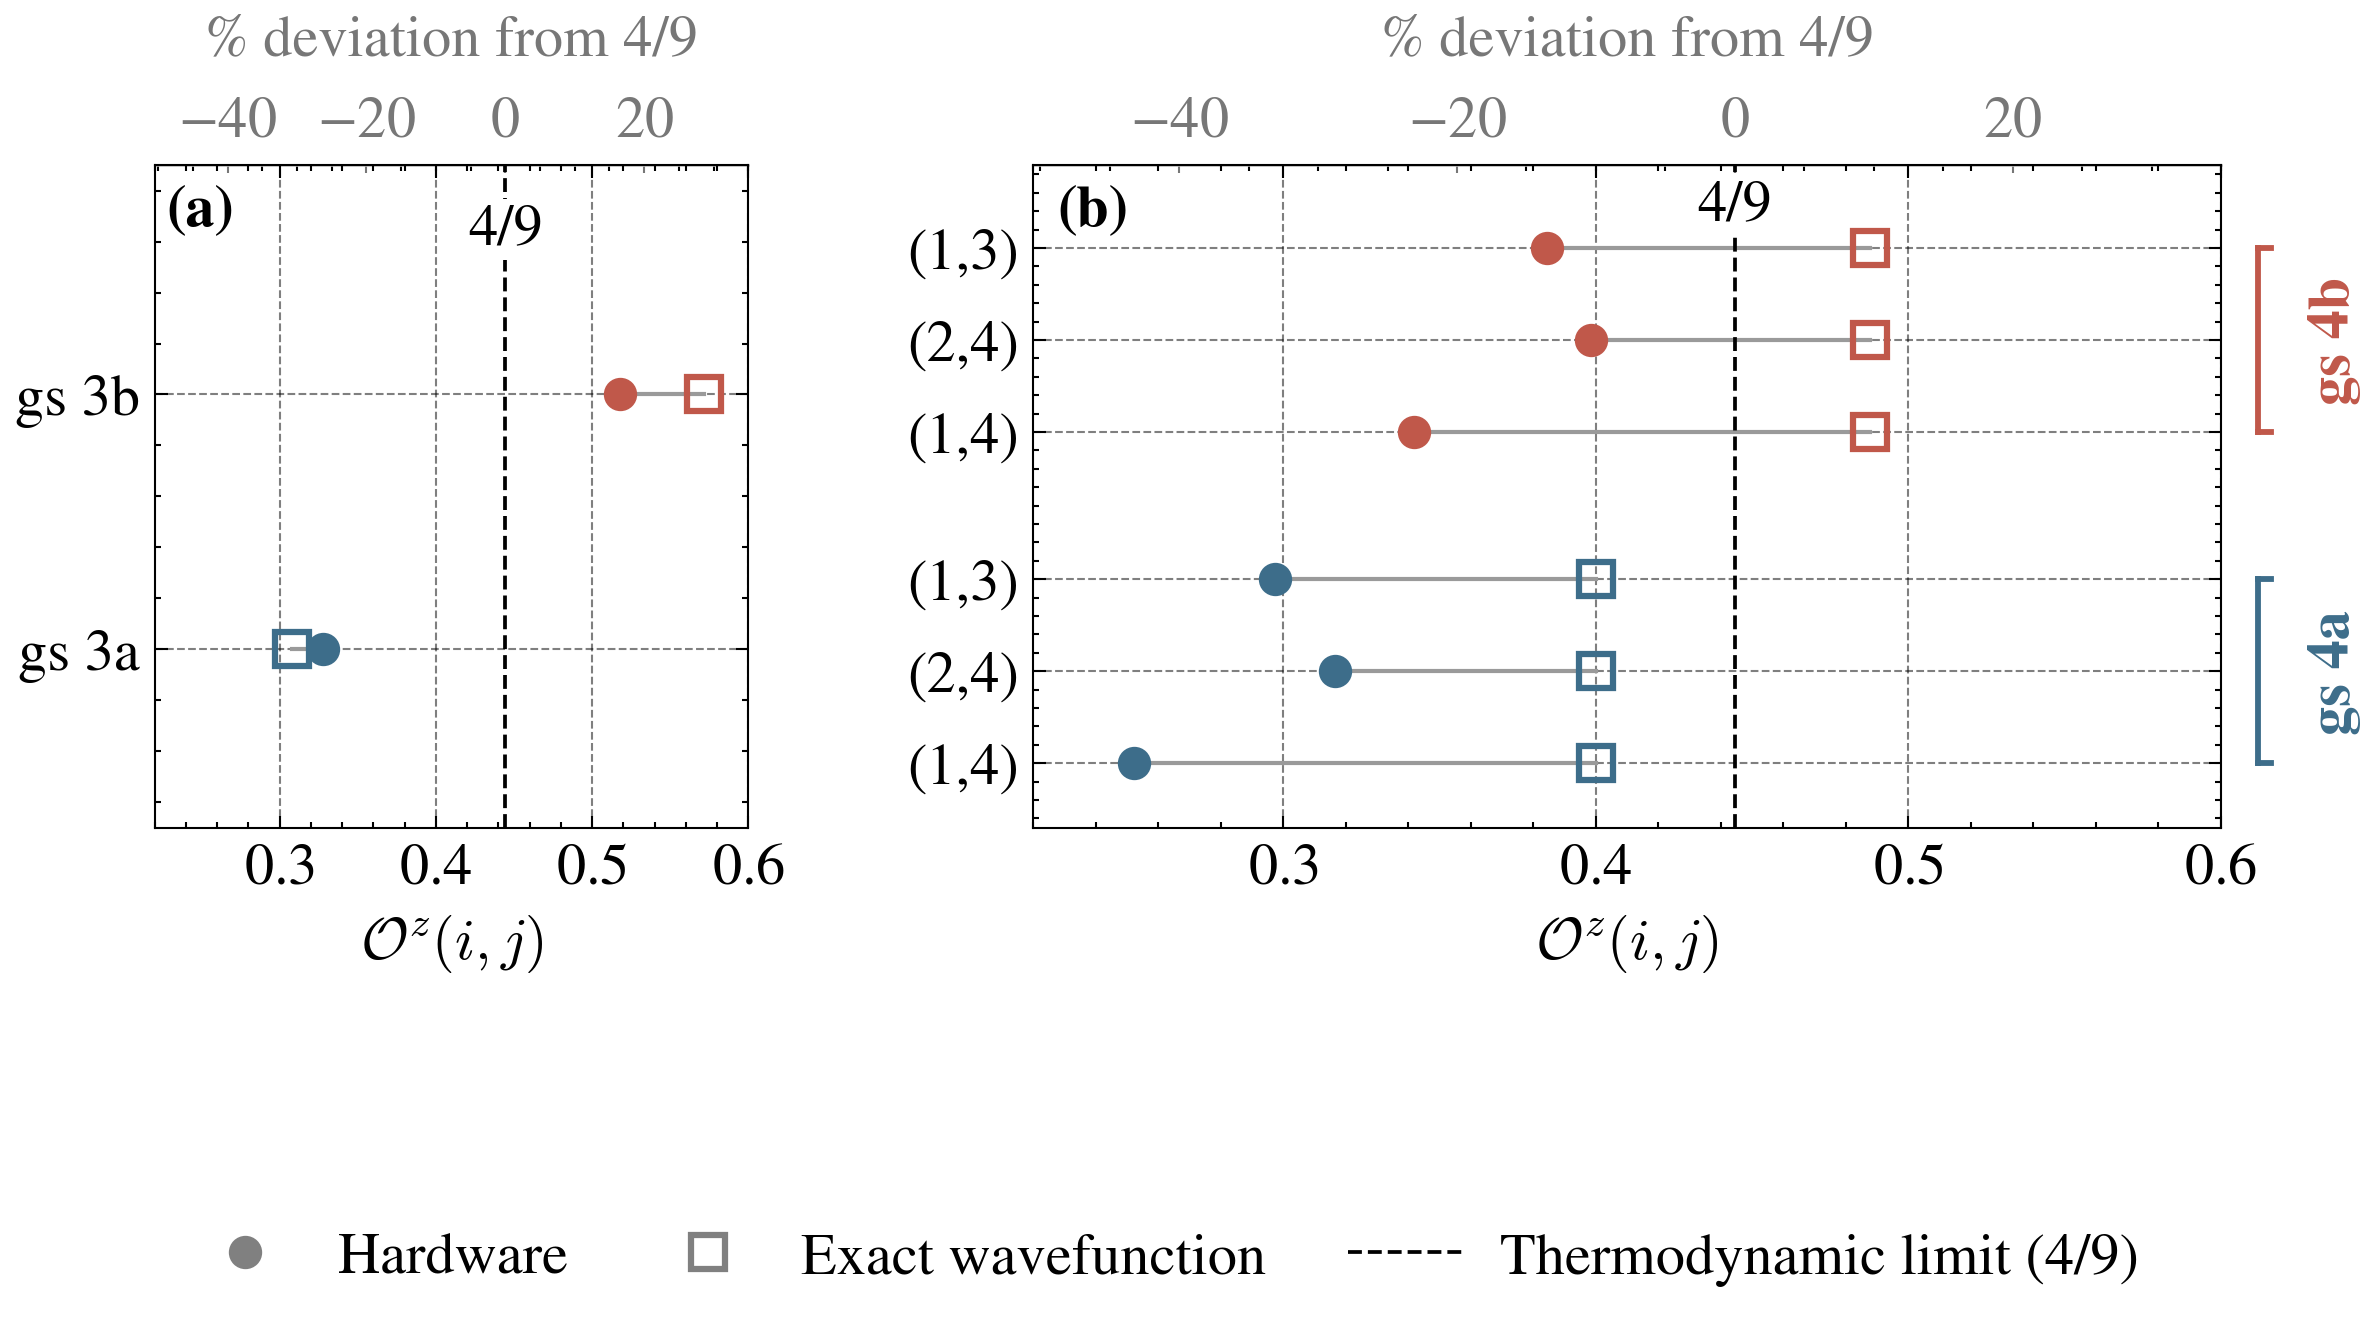

In [17]:
# ============================================================
# Cell 3 — Publication Cleveland dot plot
# ------------------------------------------------------------
# (a) n=3, longest-range O^z(1,3) only.
# (b) n=4, all pairs {(1,3), (2,4), (1,4)}.
# Open square = exact wavefunction; filled circle = hardware.
# ============================================================
def set_style():
    plt.style.use(["science", "grid", "no-latex"])
    plt.style.use(["no-latex"])
    plt.rcParams.update({
        "image.cmap": "cividis",
        "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14,
        "legend.fontsize": 14, "axes.titlesize": 14,
        "lines.linewidth": 1.5, "savefig.dpi": 300, "figure.dpi": 300,
        "axes.grid": True, "axes.spines.top": True, "axes.spines.right": True,
    })


set_style()

COLOR_B = "#c0584a"   # terracotta for *b* states
COLOR_A = "#3d6d8a"   # steel blue for *a* states
LINK    = "#9a9a9a"


def _row(state_key, pair, color):
    exact = oz_pair(state_key, "exact", pair)
    hw    = oz_pair(state_key, "hw",    pair)
    return (f"({pair[0]},{pair[1]})", exact, hw, color, state_key)


left_rows = [
    _row("gs3b", (1, 3), COLOR_B),
    _row("gs3a", (1, 3), COLOR_A),
]
right_rows = [
    _row("gs4b", (1, 3), COLOR_B),
    _row("gs4b", (2, 4), COLOR_B),
    _row("gs4b", (1, 4), COLOR_B),
    _row("gs4a", (1, 3), COLOR_A),
    _row("gs4a", (2, 4), COLOR_A),
    _row("gs4a", (1, 4), COLOR_A),
]

fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(8.4, 4.6),
    gridspec_kw={"width_ratios": [1, 2], "wspace": 0.32},
)


def draw_panel(ax, rows, panel_letter, group_gap_after=None):
    y_positions, y_cursor = [], len(rows) + (0.6 if group_gap_after is not None else 0.0)
    for idx in range(len(rows)):
        y_positions.append(y_cursor)
        y_cursor -= 1.0
        if group_gap_after is not None and idx == group_gap_after:
            y_cursor -= 0.6
    y_positions = np.array(y_positions)

    for (pair_label, exact, hw, color, _), y in zip(rows, y_positions):
        if exact is not None and hw is not None:
            x0, x1 = min(exact, hw), max(exact, hw)
            ax.plot([x0, x1], [y, y], color=LINK, linewidth=1.0, zorder=1)
        if exact is not None:
            ax.plot(exact, y, marker="s", markersize=8, markerfacecolor="none",
                    markeredgecolor=color, markeredgewidth=1.5, zorder=3)
        if hw is not None:
            ax.plot(hw, y, marker="o", markersize=7, color=color, zorder=3)

    ax.axvline(THERMO, color="black", linestyle="--", linewidth=0.9, zorder=2)

    ax.set_yticks(y_positions)
    ax.set_yticklabels([pl for (pl, _, _, _, _) in rows])

    ax.set_xlim(0.22, 0.60)
    ax.set_xlabel(r"$\mathcal{O}^z(i,j)$")
    ax.set_ylim(min(y_positions) - 0.7, max(y_positions) + 0.9)

    ymax = ax.get_ylim()[1]
    ax.text(THERMO, ymax - 0.15, "4/9", ha="center", va="top",
            fontsize=14, color="black",
            bbox=dict(facecolor="white", edgecolor="none", pad=1.0),
            zorder=4)

    secax = ax.secondary_xaxis(
        "top",
        functions=(lambda x: 100 * (x - THERMO) / THERMO,
                   lambda d: THERMO * (1 + d / 100)),
    )
    secax.set_xticks([-40, -20, 0, 20])
    secax.tick_params(axis="x", colors="#777777", labelsize=14, length=2, pad=4)
    for spine in secax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(0.6)
    secax.set_xlabel("% deviation from 4/9",
                     color="#777777", fontsize=14, labelpad=10)

    ax.text(0.02, 0.97, f"({panel_letter})", transform=ax.transAxes,
            fontsize=14, fontweight="bold", va="top", ha="left")

    return y_positions


y_left  = draw_panel(axL, left_rows,  "a")
y_right = draw_panel(axR, right_rows, "b", group_gap_after=2)

# Group brackets on the right margin of the right panel.
group_specs = [("gs 4b", y_right[:3], COLOR_B), ("gs 4a", y_right[3:], COLOR_A)]
x_bracket, x_text = 0.612, 0.628
for name, ys, color in group_specs:
    y_top, y_bot = ys.max(), ys.min()
    axR.plot([x_bracket, x_bracket], [y_bot, y_top],
             color=color, linewidth=1.4, clip_on=False, zorder=5)
    for y in (y_top, y_bot):
        axR.plot([x_bracket, x_bracket + 0.004], [y, y],
                 color=color, linewidth=1.4, clip_on=False, zorder=5)
    axR.text(x_text, 0.5 * (y_top + y_bot), name,
             color=color, fontsize=14, fontweight="bold",
             va="center", ha="left", rotation=90, clip_on=False)

# Panel (a) y-labels = state names (one pair per state).
axL.set_yticklabels(["gs 3b", "gs 3a"])

legend_handles = [
    Line2D([0], [0], marker="o", color="gray", linestyle="none",
           markersize=7, label="Hardware"),
    Line2D([0], [0], marker="s", color="gray", linestyle="none",
           markersize=8, markerfacecolor="none", markeredgewidth=1.5,
           label="Exact wavefunction"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=0.9,
           label="Thermodynamic limit (4/9)"),
]
fig.subplots_adjust(left=0.10, right=0.92, top=0.80, bottom=0.32)
fig.legend(handles=legend_handles, loc="lower center",
           bbox_to_anchor=(0.5, -0.05), ncol=3,
           frameon=False, handletextpad=0.6, columnspacing=1.4)
plt.savefig("string_order_plot.pdf", bbox_inches="tight")
plt.show()


In [15]:
# ============================================================
# Cell 4 — Summary table: O^z(i,j) for every state and pair
# ------------------------------------------------------------
# Columns: state, kind, n, pair, r, O^z, deviation, % dev.
# n=2 rows are skipped (no string-order pair exists for n=2).
# ============================================================
import pandas as pd

rows_out = []
for name, s in STATES.items():
    n = s["n"]
    for kind in ("hw", "exact"):
        vec = s[kind]
        if vec is None:
            continue
        results, _ = compute_string_order(vec)
        for (i, j), d in sorted(results.items()):
            oz = d["string_order"]
            rows_out.append({
                "state":    name,
                "kind":     "HW" if kind == "hw" else "exact",
                "n":        n,
                "pair":     f"({i},{j})",
                "r":        j - i,
                "O^z":      round(oz, 4),
                "Δ vs 4/9": round(oz - THERMO, 4),
                "% dev":    f"{100 * (oz - THERMO) / THERMO:+.1f}%",
            })

df = pd.DataFrame(rows_out).sort_values(by=["n", "pair", "kind", "state"]).reset_index(drop=True)
with pd.option_context("display.max_rows", None, "display.width", 120):
    print(df.to_string(index=False))

try:
    from IPython.display import display
    display(df)
except Exception:
    pass


state  kind  n  pair  r    O^z  Δ vs 4/9  % dev
 gs3a    HW  3 (1,3)  2 0.3277   -0.1167 -26.3%
 gs3b    HW  3 (1,3)  2 0.5179    0.0734 +16.5%
 gs3a exact  3 (1,3)  2 0.3077   -0.1368 -30.8%
 gs3b exact  3 (1,3)  2 0.5714    0.1270 +28.6%
 gs4a    HW  4 (1,3)  2 0.2973   -0.1472 -33.1%
 gs4b    HW  4 (1,3)  2 0.3844   -0.0601 -13.5%
 gs4a exact  4 (1,3)  2 0.4000   -0.0444 -10.0%
 gs4b exact  4 (1,3)  2 0.4878    0.0434  +9.8%
 gs4a    HW  4 (1,4)  3 0.2521   -0.1924 -43.3%
 gs4b    HW  4 (1,4)  3 0.3418   -0.1027 -23.1%
 gs4a exact  4 (1,4)  3 0.4000   -0.0444 -10.0%
 gs4b exact  4 (1,4)  3 0.4878    0.0434  +9.8%
 gs4a    HW  4 (2,4)  2 0.3165   -0.1280 -28.8%
 gs4b    HW  4 (2,4)  2 0.3984   -0.0460 -10.4%
 gs4a exact  4 (2,4)  2 0.4000   -0.0444 -10.0%
 gs4b exact  4 (2,4)  2 0.4878    0.0434  +9.8%


,state,kind,n,pair,r,O^z,Δ vs 4/9,% dev
0,gs3a,HW,3,"(1,3)",2,0.3277,-0.1167,-26.3%
1,gs3b,HW,3,"(1,3)",2,0.5179,0.0734,+16.5%
2,gs3a,exact,3,"(1,3)",2,0.3077,-0.1368,-30.8%
3,gs3b,exact,3,"(1,3)",2,0.5714,0.1270,+28.6%
4,gs4a,HW,4,"(1,3)",2,0.2973,-0.1472,-33.1%
5,gs4b,HW,4,"(1,3)",2,0.3844,-0.0601,-13.5%
6,gs4a,exact,4,"(1,3)",2,0.4000,-0.0444,-10.0%
7,gs4b,exact,4,"(1,3)",2,0.4878,0.0434,+9.8%
8,gs4a,HW,4,"(1,4)",3,0.2521,-0.1924,-43.3%
9,gs4b,HW,4,"(1,4)",3,0.3418,-0.1027,-23.1%
